In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [2]:
df=pd.read_csv("bitcoin_dataset.csv")

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4280 entries, 0 to 4279
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4280 non-null   object 
 1   Open       4280 non-null   float64
 2   High       4280 non-null   float64
 3   Low        4280 non-null   float64
 4   Close      4280 non-null   float64
 5   Adj Close  4280 non-null   float64
 6   Volume     4280 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 234.2+ KB


,Open,High,Low,Close,Adj Close,Volume
count,4280.000000,4280.000000,4280.000000,4280.000000,4280.000000,4.280000e+03
mean,28623.330630,29188.324150,28019.749124,28636.451670,28636.451670,2.230348e+10
std,32442.204251,32986.012544,31852.792883,32442.454923,32442.454923,2.294359e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,3452.187439,3504.092224,3391.943420,3458.813721,3458.813721,1.676575e+09
50%,11536.727539,11850.328613,11288.414062,11564.331543,11564.331543,1.802679e+10
75%,46401.472656,47432.591797,45184.174805,46446.924805,46446.924805,3.446429e+10
max,124752.140625,126198.070312,123196.046875,124752.531250,124752.531250,3.509679e+11


In [6]:
df["Date"]=pd.to_datetime(df["Date"])

In [7]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [9]:
print(df["Date"].min())
print(df["Date"].max())

2014-09-17 00:00:00
2026-06-05 00:00:00


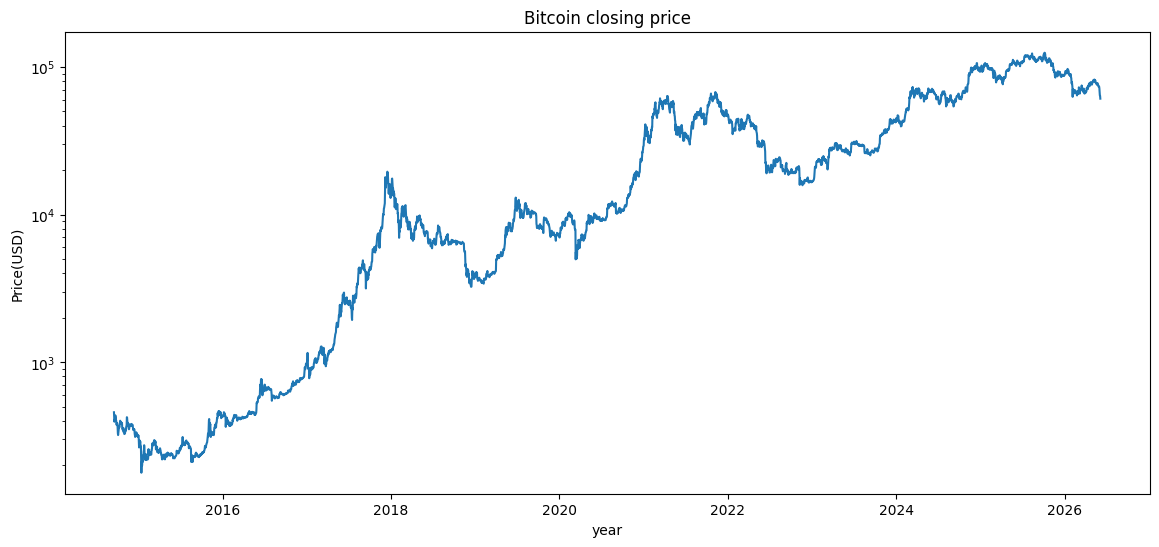

In [14]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Close"])
plt.yscale("log")
plt.xlabel("year")
plt.ylabel("Price(USD)")
plt.title("Bitcoin closing price")
plt.show()

In [16]:
df["Daily_return"]=df["Close"].pct_change()
print(df[["Date","Close","Daily_return"]].head(10))

        Date       Close  Daily_return
0 2014-09-17  457.334015           NaN
1 2014-09-18  424.440002     -0.071926
2 2014-09-19  394.795990     -0.069843
3 2014-09-20  408.903992      0.035735
4 2014-09-21  398.821014     -0.024659
5 2014-09-22  402.152008      0.008352
6 2014-09-23  435.790985      0.083647
7 2014-09-24  423.204987     -0.028881
8 2014-09-25  411.574005     -0.027483
9 2014-09-26  404.424988     -0.017370


In [18]:
df["Daily_return"].describe()

,Daily_return
count,4279.000000
mean,0.001758
std,0.034916
min,-0.371695
25%,-0.012617
50%,0.001073
75%,0.015884
max,0.252472


In [20]:
best_day=df.loc[df["Daily_return"].idxmax()]
worst_day=df.loc[df["Daily_return"].idxmin()]
print("best_day")
print(best_day[["Date","Close","Daily_return"]])
print()
print("worst_day")
print(worst_day[["Date","Close","Daily_return"]])

best_day
Date            2017-12-07 00:00:00
Close                  17899.699219
Daily_return               0.252472
Name: 1177, dtype: object

worst_day
Date            2020-03-12 00:00:00
Close                   4970.788086
Daily_return              -0.371695
Name: 2003, dtype: object


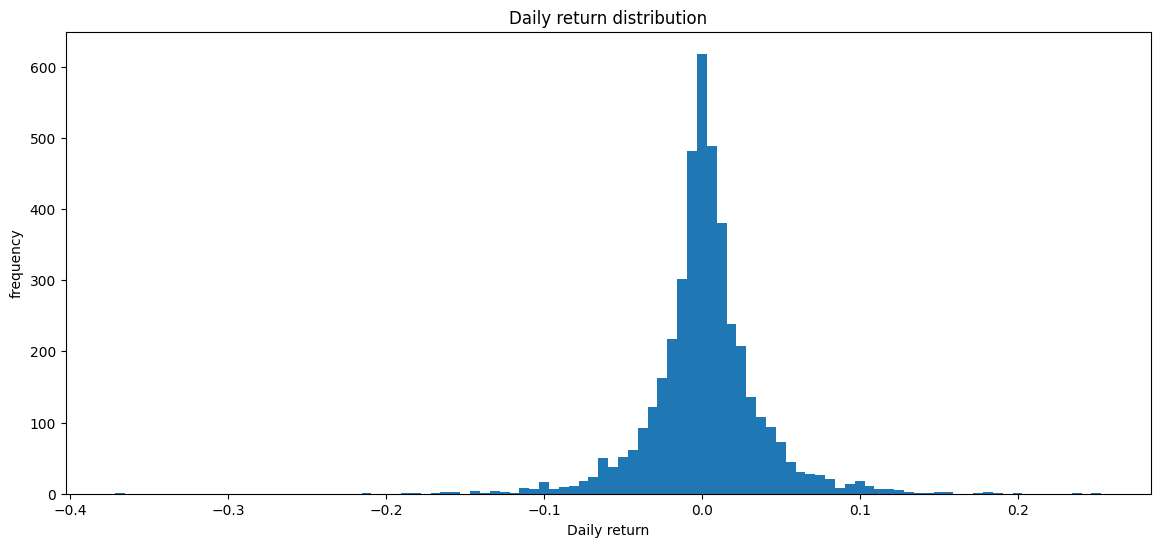

In [22]:
plt.figure(figsize=(14,6))
plt.hist(df["Daily_return"].dropna(),bins=100)
plt.title("Daily return distribution")
plt.xlabel("Daily return")
plt.ylabel("frequency")
plt.show()

In [26]:
df["Volatility"]=df["Daily_return"].rolling(30).std()

In [27]:
df["Volatility"].describe()

,Volatility
count,4250.000000
mean,0.031658
std,0.014492
min,0.007095
25%,0.021524
50%,0.028636
75%,0.038794
max,0.091330


In [28]:
print(df["Volatility"].head(35))

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9          NaN
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
15         NaN
16         NaN
17         NaN
18         NaN
19         NaN
20         NaN
21         NaN
22         NaN
23         NaN
24         NaN
25         NaN
26         NaN
27         NaN
28         NaN
29         NaN
30    0.039148
31    0.037290
32    0.035033
33    0.034508
34    0.034284
Name: Volatility, dtype: float64


In [29]:
max_vol=df.loc[df["Volatility"].idxmax()]
print(max_vol[["Date","Close","Volatility"]])

Date          2020-04-06 00:00:00
Close                  7271.78125
Volatility                0.09133
Name: 2028, dtype: object


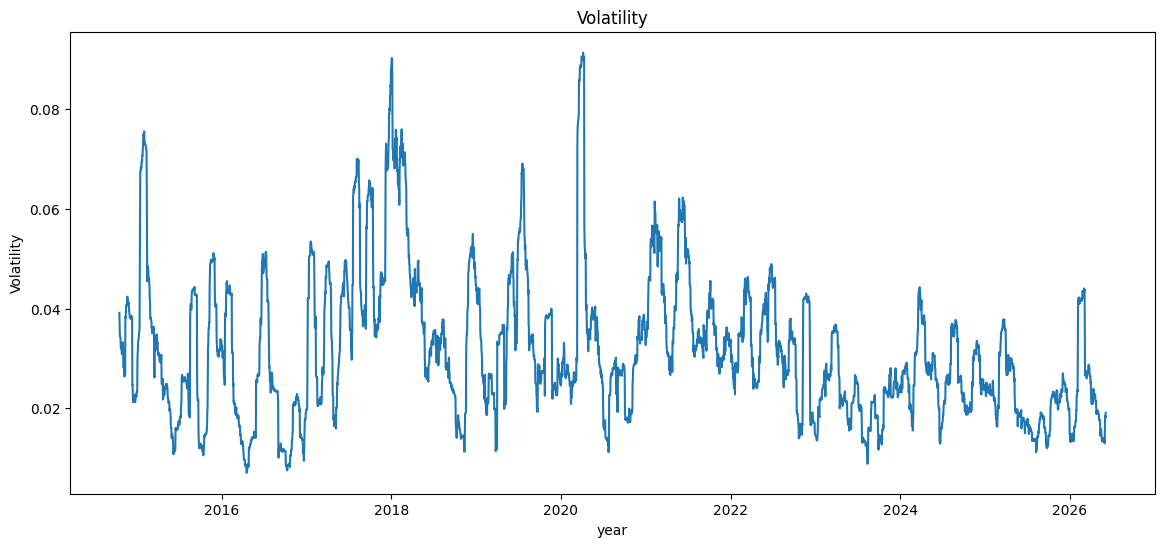

In [30]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Volatility"])
plt.title("Volatility")
plt.xlabel("year")
plt.ylabel("Volatility")
plt.show()

In [31]:
df[["Volume","Volatility"]].corr()

,Volume,Volatility
Volume,1.000000,-0.024534
Volatility,-0.024534,1.000000


In [32]:
df["avg_vol_30"]=df["Volume"].rolling(30).mean()

In [33]:
df[["Volatility","avg_vol_30"]].corr()

,Volatility,avg_vol_30
Volatility,1.00000,-0.00464
avg_vol_30,-0.00464,1.00000


In [34]:
corr=df.corr(numeric_only=True)
print(corr["Volatility"].sort_values(ascending=False))

Volatility      1.000000
Daily_return    0.017981
avg_vol_30     -0.004640
Volume         -0.024534
High           -0.231001
Adj Close      -0.234677
Close          -0.234677
Open           -0.234915
Low            -0.239657
Name: Volatility, dtype: float64


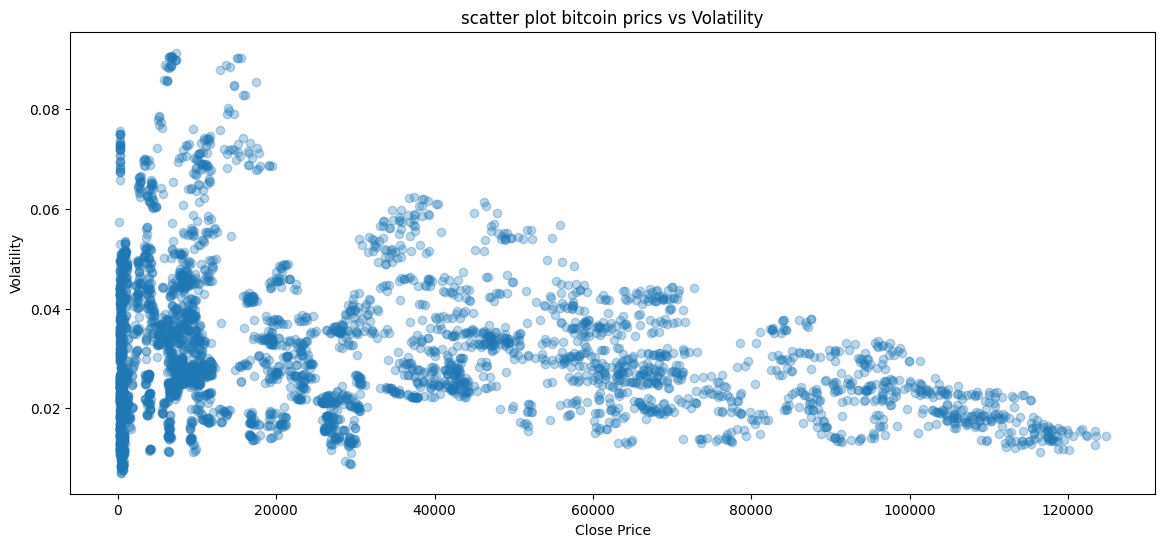

In [37]:
plt.figure(figsize=(14,6))
plt.scatter(df["Close"],df["Volatility"],alpha=0.3)
plt.xlabel("Close Price")
plt.ylabel("Volatility")
plt.title("scatter plot bitcoin prics vs Volatility")
plt.show()

In [38]:
df["Year"]=df["Date"].dt.year
df.groupby("Year")["Volatility"].mean()

,Volatility
Year,
2014,0.032323
2015,0.032067
2016,0.022389
2017,0.044610
2018,0.040839
2019,0.034379
2020,0.033017
2021,0.040912
2022,0.032613


In [39]:
df["MA7"]=df["Close"].rolling(7).mean()
df["MA30"]=df["Close"].rolling(30).mean()
df["MA90"]=df["Close"].rolling(90).mean()

In [40]:
df[["Date","Close","MA7","MA30","MA90"]].tail(10)

,Date,Close,MA7,MA30,MA90
4270,2026-05-27,74344.703125,76304.610491,78381.463281,73576.935938
4271,2026-05-28,73536.554688,75732.808036,78287.659375,73661.988802
4272,2026-05-29,73372.523438,75430.562500,78207.539062,73732.840625
4273,2026-05-30,73754.835938,75013.629464,78122.556250,73821.915451
4274,2026-05-31,73579.687500,74527.709821,77969.245833,73875.291406
4275,2026-06-01,71319.773438,73676.258929,77724.663281,73908.915017
4276,2026-06-02,66703.656250,72373.104911,77330.177604,73842.171441
4277,2026-06-03,64014.367188,70897.342634,76803.059635,73766.318576
4278,2026-06-04,63801.574219,69506.631138,76232.210286,73718.152821
4279,2026-06-05,60922.667969,67728.080357,75548.714844,73647.598090


In [41]:
df["Price_vs_MA30"]=((df["Close"]-df["MA30"])/df["MA30"])*100

In [43]:
df["Price_vs_MA30"].tail(40)

,Price_vs_MA30
4240,6.241192
4241,4.349516
4242,3.137429
4243,3.477425
4244,5.537842
4245,5.624101
4246,4.919164
4247,6.049980
4248,6.944481
4249,7.013427


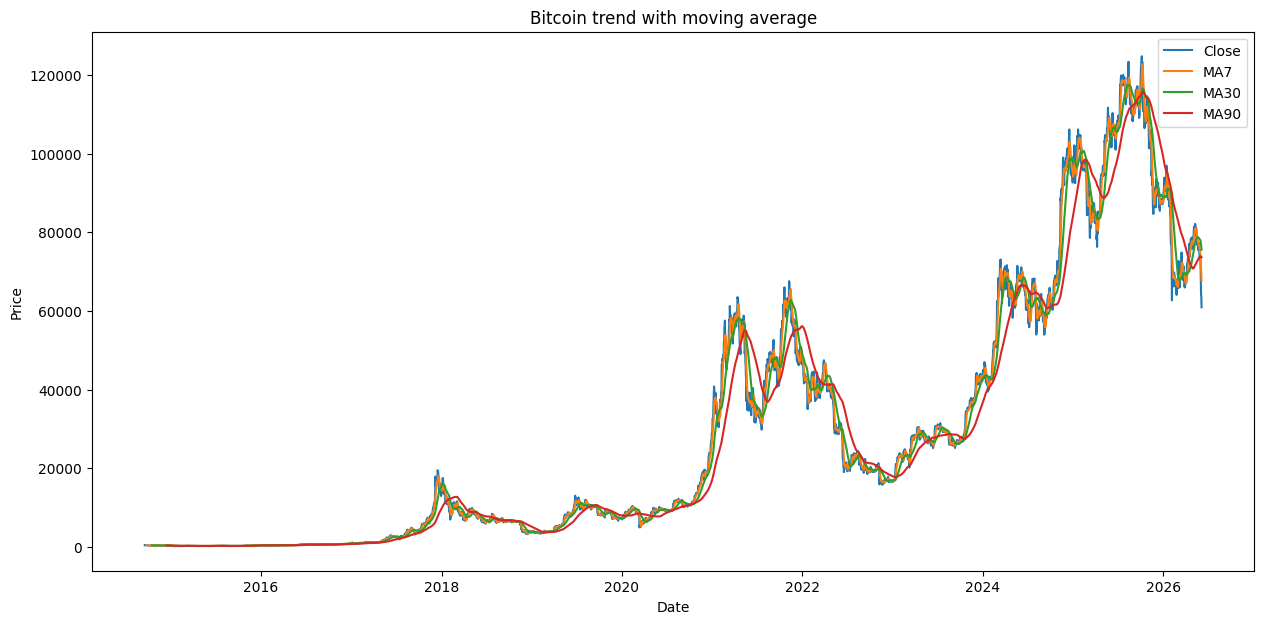

In [45]:
plt.figure(figsize=(15,7))
plt.plot(df["Date"],df["Close"],label="Close")
plt.plot(df["Date"],df["MA7"],label="MA7")
plt.plot(df["Date"],df["MA30"],label="MA30")
plt.plot(df["Date"],df["MA90"],label="MA90")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.title("Bitcoin trend with moving average")
plt.show()

In [65]:
df["MA7_vs_MA30_ratio"]=df["MA7"]/df["MA30"]
df["Close_vs_MA30_ratio"]=df["Close"]/df["MA30"]
df["Close_vs_MA30_ratio"].tail()

,Close_vs_MA30_ratio
4275,0.917595
4276,0.862582
4277,0.833487
4278,0.836937
4279,0.806402


In [47]:
df["Delta"]=df["Close"].diff()

In [48]:
df["Delta"].head(20)

,Delta
0,NaN
1,-32.894012
2,-29.644012
3,14.108002
4,-10.082977
5,3.330994
6,33.638977
7,-12.585999
8,-11.630981
9,-7.149017


In [49]:
df["Gain"]=df["Delta"].clip(lower=0)
df["Loss"]=-df["Delta"].clip(upper=0)

In [52]:
df["Avg_gain"]=df["Gain"].rolling(14).mean()
df["Avg_loss"]=df["Loss"].rolling(14).mean()

In [53]:
df["RS"]=df["Avg_gain"]/df["Avg_loss"]
df["RSI"]=100-(100/(1+df["RS"]))

In [54]:
df[["Date","Close","RSI"]].tail(10)

,Date,Close,RSI
4270,2026-05-27,74344.703125,31.920080
4271,2026-05-28,73536.554688,20.355300
4272,2026-05-29,73372.523438,23.771660
4273,2026-05-30,73754.835938,28.756698
4274,2026-05-31,73579.687500,30.307003
4275,2026-06-01,71319.773438,25.627508
4276,2026-06-02,66703.656250,18.546871
4277,2026-06-03,64014.367188,12.561952
4278,2026-06-04,63801.574219,12.020615
4279,2026-06-05,60922.667969,11.494390


In [87]:
df["Target"]=(df["Close"].shift(-1)>df["Close"]).astype(int)
df["target_7D"]=(df["Close"].shift(-7)>df["Close"]).astype(int)

In [56]:
df["Target"].tail(10)

,Target
4270,0
4271,0
4272,1
4273,0
4274,0
4275,0
4276,0
4277,0
4278,0
4279,0


In [57]:
df["Target"].value_counts()

,count
Target,
1,2242
0,2038


In [88]:
df_ml=df.dropna().copy()
df_ml.shape

(4191, 28)

In [89]:
df_ml.columns.tolist()

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'Daily_return',
 'Volatility',
 'avg_vol_30',
 'Year',
 'MA7',
 'MA30',
 'MA90',
 'Price_vs_MA30',
 'MA7_vs_MA30',
 'Close_vs_MA30',
 'Delta',
 'Gain',
 'Loss',
 'Avg_gain',
 'Avg_loss',
 'RS',
 'RSI',
 'Target',
 'MA7_vs_MA30_ratio',
 'Close_vs_MA30_ratio',
 'target_7D']

In [62]:
features=["Daily_return","Volatility","RSI","Close_vs_MA30_ratio","MA7_vs_MA30_ratio"]

In [90]:
X=df_ml[features]
Y=df_ml["Target"]
Z=df_ml["target_7D"]
print(X.head())
print()
print(Y.head())
print()
print(Z.head())

    Daily_return  Volatility        RSI  Close_vs_MA30_ratio  \
89     -0.017879    0.021259  27.102635             0.940115   
90     -0.052941    0.022171  19.939262             0.895285   
91     -0.022277    0.022366  19.724827             0.880776   
92     -0.026206    0.022178  19.102052             0.862748   
93      0.020704    0.022410  18.406462             0.885740   

    MA7_vs_MA30_ratio  
89           0.951226  
90           0.946667  
91           0.942083  
92           0.932154  
93           0.923771  

89    0
90    0
91    0
92    1
93    1
Name: Target, dtype: int64

89    0
90    1
91    1
92    1
93    1
Name: target_7D, dtype: int64


In [91]:
split=int(len(df_ml)*0.8)
X_train=X[:split]
X_test=X[split:]
Y_train=Y[:split]
Y_test=Y[split:]
Z_train=Z[:split]
Z_test=Z[split:]

In [73]:
print(X_train.shape)
print(X_test.shape)

(3352, 5)
(839, 5)


In [92]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression(max_iter=1000)
model1.fit(X_train,Y_train)
model2=LogisticRegression(max_iter=1000)
model2.fit(X_train,Z_train)

LogisticRegression(max_iter=1000)

In [93]:
pred1=model1.predict(X_test)
pred2=model2.predict(X_test)

In [95]:
from sklearn.metrics import accuracy_score
accuracy1=accuracy_score(Y_test,pred1)
print(accuracy1)
accuracy2=accuracy_score(Z_test,pred2)
print(accuracy2)

0.4922526817640048
0.5113230035756854


In [96]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,pred1))
print(classification_report(Z_test,pred2))

              precision    recall  f1-score   support

           0       0.47      0.08      0.14       421
           1       0.49      0.91      0.64       418

    accuracy                           0.49       839
   macro avg       0.48      0.49      0.39       839
weighted avg       0.48      0.49      0.39       839

              precision    recall  f1-score   support

           0       0.46      0.08      0.14       405
           1       0.52      0.91      0.66       434

    accuracy                           0.51       839
   macro avg       0.49      0.50      0.40       839
weighted avg       0.49      0.51      0.41       839



In [97]:
for feature, coef in zip(features,model1.coef_[0]):
  print(feature, coef)

Daily_return -1.5854249912915552
Volatility -0.1781744153830125
RSI 0.006880127503994127
Close_vs_MA30_ratio -0.8277268587564278
MA7_vs_MA30_ratio 0.5583855784858629


In [82]:
Y_test.value_counts(normalize=True)

,proportion
Target,
0,0.501788
1,0.498212


In [99]:
print(df_ml.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_return', 'Volatility', 'avg_vol_30', 'Year', 'MA7', 'MA30', 'MA90', 'Price_vs_MA30', 'MA7_vs_MA30', 'Close_vs_MA30', 'Delta', 'Gain', 'Loss', 'Avg_gain', 'Avg_loss', 'RS', 'RSI', 'Target', 'MA7_vs_MA30_ratio', 'Close_vs_MA30_ratio', 'target_7D']


In [101]:
corr = df_ml[[
    "Daily_return",
    "Volatility",
    "RSI",
    "Close_vs_MA30_ratio",
    "MA7_vs_MA30_ratio",
    "target_7D"
]].corr()

print(corr["target_7D"].sort_values(ascending=False))

target_7D              1.000000
RSI                    0.060660
MA7_vs_MA30_ratio      0.042103
Close_vs_MA30_ratio    0.036254
Volatility             0.002403
Daily_return          -0.013400
Name: target_7D, dtype: float64
